# Signal engine + backtester

A research surface over the `qbt` package. The design principle the whole
thing is built around:

> A strategy is a **pure function** from a *price panel sliced to the decision
> bar* to *target portfolio weights*. Nothing else. The backtester and the live
> runner both call that same function, so there is exactly one implementation
> of your logic and no opportunity for research and production to drift apart.

Everything else follows from that. The panel slicing is the look-ahead
firewall. Weights-not-shares is what makes strategies composable. Keeping the
risk gate outside the strategy is what lets you change risk policy without
touching signal code.

```
qbt/data.py         PricePanel + as_of() firewall, OpenBB and synthetic sources
qbt/fundamentals.py FundamentalsPanel -- point-in-time filings/ratios, per symbol
qbt/macro.py        MacrosPanel -- point-in-time macro indicators, economy-wide
qbt/corporate.py    CorpsPanel -- filing cadence + insider-trading indicators
qbt/options.py      OptionsPanel -- options-chain-derived indicators
qbt/signals.py      Strategy protocol + concrete strategies
qbt/risk.py         RiskGate: vol target, caps, drawdown breaker, PDT ledger
qbt/engine.py       Backtester (T+1 fills, costs) + performance metrics
qbt/research.py     IC diagnostics, walk-forward, multiple-testing haircut
qbt/live.py         LiveSignalRunner -> order intents (no execution)
```

The four newer panels all share the same `as_of()` look-ahead firewall as
`PricePanel` -- a strategy that reads them is structurally unable to see a
filing, a macro release, or an options snapshot before it actually happened.
Section 4 covers them and the strategies built on them.

**Running this.** `USE_OPENBB = True` (the default) runs on real ETF data
via `openbb-yfinance`, hitting the network and caching under
`.cache/prices`. Set it to `False` to run fully offline on generated data
with known structure -- useful when you want a signal whose answer you
already know, or no network. Nothing else in the notebook changes, which
is the point of the repository abstraction.

In [1]:
# Locate the project and make its qbt package win over anything else on
# sys.path. Search up from the working directory, then fall back to the
# known project path -- Jupyter is not always launched from the project.
import os
import pathlib
import sys
import warnings

PROJECT_ROOT = pathlib.Path('/Users/socrates/Documents/notebooks/AI-trader2')

_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents,
                          PROJECT_ROOT]
              if (p / 'qbt' / '__init__.py').is_file()), None)
if _root is None:
    raise RuntimeError(f'No qbt/ package found at or above {pathlib.Path.cwd()}, '
                       f'nor at {PROJECT_ROOT}. Edit PROJECT_ROOT above.')

os.chdir(_root)
if str(_root) in sys.path:
    sys.path.remove(str(_root))
sys.path.insert(0, str(_root))
for _stale in [m for m in sys.modules if m == 'qbt' or m.startswith('qbt.')]:
    del sys.modules[_stale]
print(f'project root: {_root}')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qbt import (
    Backtester, CalendarSeasonality, Composite, CorpsPanel,
    CorpsRepository, CostModel, CrossSectionalMomentum, DayTradeLedger,
    EqualWeightBuyHold, ExecutionConfig, FundamentalsPanel,
    FundamentalsRepository, FundamentalsValueFilter, InsiderEventDrift,
    InverseVolWeighted, LiveSignalRunner, MacroRegimeFilter, MacrosPanel,
    MacrosRepository, MultiFactorCrossSectional, OpenBBRepository,
    OptionsMeanReversion, OptionsPanel, OptionsRepository, PairsTrading,
    ParameterSweep, PortfolioState, RiskGate, RiskParityAllocation,
    ShortHorizonReversal, SyntheticRepository, TimeSeriesMomentum,
    TrendFilter, compare, expected_max_sharpe, forward_returns, ic_grid,
    ic_summary, information_coefficient, return_autocorrelation,
    sharpe_haircut, summary_stats, trailing_signal, walk_forward_splits,
)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 160, 'display.max_columns', 40)
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

USE_OPENBB = True         # real ETF data; set False to run fully offline
PROVIDER = 'yfinance'
START = '2010-01-01'
END = str(pd.Timestamp.today().normalize().date())   # never stale
INITIAL_EQUITY = 25_000.0

print('ready')

project root: /Users/socrates/Applications/AI-trader
ready


---
## 1. Data

The universe is liquid sector and asset-class ETFs. That choice is not
incidental: ETFs like these essentially do not get delisted, so a backtest on
them is close to free of **survivorship bias**. Run the same study on
"today's S&P 500 constituents over the last 15 years" and you have silently
conditioned on surviving, which inflates returns by a percent or two a year
before you write a single line of strategy.

`XLC` (2018) and `XLRE` (2015) start mid-sample. The panel handles ragged
starts, and strategies only score names with sufficient history — so those two
simply become tradeable when they exist, which is the correct behaviour.

**The universe is deliberately mixed, and that has a cost you should price
in.** The 18 ETFs are there for breadth across asset classes; the 12
individual equities are there because fundamentals and insider filings do
not exist for funds, so section 4's panels would otherwise be permanently
synthetic. But single stocks run roughly **1.5x** the volatility of sector
ETFs here — measured on this data, median 24.1% against 16.4% annualised.

`CrossSectionalMomentum` ranks on trailing *return*, not risk-adjusted
return, so the higher-vol names occupy both tails of the ranking
disproportionately and the top-`n` picks skew toward the equities. That is
a selection bias, not a signal. `RiskGate` still controls *total* book
volatility, so this does not blow up the risk target — it changes *which
names get chosen*. Two honest ways to handle it: wrap the strategy in
`InverseVolWeighted` so sizing offsets the dispersion, or rank within
vol buckets. Compare against `ETFS`-only to see how much of any result
is really this effect.

In [2]:
ETFS = [
    'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV',
    'XLY',                      # 11 GICS sectors
    'IWM', 'EFA', 'EEM',        # small cap, developed intl, emerging
    'TLT', 'IEF', 'GLD', 'DBC', # duration, gold, broad commodities
]

# Individual equities, one per sector, all continuously listed since 2010.
# These are what make the fundamentals and filings panels in section 4 mean
# anything: an ETF has no income statement, no P/E and no Form 4 insider
# transactions, because it is a fund rather than an issuer. On an
# ETF-only universe those two panels can only ever be stand-ins, whatever
# credentials you hold -- CorpsRepository raises outright ('No Form 4 data
# was returned for XLK').
EQUITIES = [
    'AAPL', 'MSFT', 'CSCO',     # tech
    'JNJ', 'PFE',               # healthcare
    'JPM',                      # financials
    'XOM', 'CVX',               # energy
    'PG', 'KO', 'WMT',          # staples
    'HD',                       # discretionary
]

UNIVERSE = ETFS + EQUITIES
BENCHMARK = 'SPY'

if USE_OPENBB:
    repo = OpenBBRepository(provider=PROVIDER, cache_dir='.cache/prices')
    panel = repo.fetch(UNIVERSE, START, END)
    bench = repo.fetch([BENCHMARK], START, END)
else:
    # Structure is known here, which is what makes it useful for validation:
    # persistent expected returns produce cross-sectional momentum, and the
    # negative lag-1 term produces short-horizon reversal.
    repo = SyntheticRepository(n_symbols=18, seed=42, mu_persistence=0.98,
                              mu_scale=0.0003, reversal_theta=0.10)
    panel = repo.fetch(start=START, end=END)
    bench = None

print(panel.describe())
panel.close.tail(3).iloc[:, :6].round(2)

PricePanel(30 symbols, 4184 bars, 2010-01-04 to 2026-08-21)


,XLB,XLC,XLE,XLF,XLI,XLK
date,,,,,,
2026-08-19,52.52,111.32,63.58,57.48,181.95,183.64
2026-08-20,52.42,110.68,63.75,56.95,179.77,183.10
2026-08-21,53.60,111.28,63.99,57.56,180.16,182.41


In [3]:
# Sanity-check the data before trusting anything downstream. Cheap, and it
# catches provider problems that would otherwise look like alpha.
rets = panel.returns()
diagnostics = pd.DataFrame({
    'first_obs': panel.close.apply(lambda s: s.first_valid_index()),
    'n_obs': panel.close.notna().sum(),
    'ann_vol': panel.close.pct_change(fill_method=None).std() * np.sqrt(252),
    'max_1d_move': rets.abs().max(),
    'internal_gaps': panel.close.apply(
        lambda s: int(s.loc[s.first_valid_index():].isna().sum())),
})
print('suspicious single-day moves (possible unadjusted splits):')
print(diagnostics[diagnostics.max_1d_move > 0.25].round(3))
diagnostics.round(3)

suspicious single-day moves (possible unadjusted splits):
Empty DataFrame
Columns: [first_obs, n_obs, ann_vol, max_1d_move, internal_gaps]
Index: []


/var/folders/8g/3lrn58911zx5zb3l5bh3w7n40000gn/T/ipykernel_8269/1415334412.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(diagnostics[diagnostics.max_1d_move > 0.25].round(3))
/var/folders/8g/3lrn58911zx5zb3l5bh3w7n40000gn/T/ipykernel_8269/1415334412.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  diagnostics.round(3)


,first_obs,n_obs,ann_vol,max_1d_move,internal_gaps
XLB,2010-01-04,4184,0.208,0.118,0
XLC,2018-06-19,2055,0.222,0.113,0
XLE,2010-01-04,4184,0.272,0.201,0
XLF,2010-01-04,4184,0.218,0.137,0
XLI,2010-01-04,4184,0.194,0.127,0
XLK,2010-01-04,4184,0.221,0.138,0
XLP,2010-01-04,4184,0.139,0.094,0
XLRE,2015-10-08,2733,0.203,0.160,0
XLU,2010-01-04,4184,0.175,0.128,0
XLV,2010-01-04,4184,0.162,0.099,0


---
## 2. Hypothesis formation

This is the section people skip, and skipping it is why most retail backtests
are elaborate curve fits. The question to answer **before** writing a strategy:
*does this universe, over this period, reward the behaviour I am about to code,
and at what horizon?*

Two independent lenses:

1. **Time-series autocorrelation** — does a name's own return predict its next
   return? Negative at short lags is the signature of reversal.
2. **Cross-sectional information coefficient** — does ranking the universe by a
   trailing return predict the ranking of forward returns? This is the one that
   matters for a long-only relative-strength strategy, because that is
   literally what such a strategy does.

In [4]:
# Each symbol is standardised before pooling, so this reads as the
# typical name rather than whichever name happens to be loudest --
# without that, a single high-vol symbol can flip the sign of the
# whole figure, which is the only thing this table is read for.
ac = return_autocorrelation(panel, lags=[1, 2, 3, 5, 10, 21])
print(ac.round(4).to_string())
print()
print('Reading it: |t| > 2 is a real effect at this sample size.')
print('n_effective (distinct dates) is what the t-stat is built on --')
print('the raw pooled n treats every (symbol, date) pair as independent.')
print('Negative at lag 1 => yesterday\'s move partly reverses today.')

     autocorr  t_stat         n  n_effective
lag                                         
1     -0.0579 -3.7412  121880.0       4182.0
2      0.0264  1.7073  121850.0       4181.0
3     -0.0249 -1.6068  121820.0       4180.0
5      0.0041  0.2631  121760.0       4178.0
10    -0.0068 -0.4401  121610.0       4173.0
21     0.0095  0.6121  121280.0       4162.0

Reading it: |t| > 2 is a real effect at this sample size.
n_effective (distinct dates) is what the t-stat is built on --
the raw pooled n treats every (symbol, date) pair as independent.
Negative at lag 1 => yesterday's move partly reverses today.


### The IC grid

For every pair of *formation window* (how far back the signal looks) and
*holding horizon* (how far forward we measure), compute the mean cross-sectional
rank correlation between them.

- **Positive** cells: names that went up keep going up → momentum.
- **Negative** cells: names that went up give it back → reversal.

Observations are subsampled to be non-overlapping. Overlapping windows are
serially correlated and inflate t-statistics substantially — sometimes by 2-3x —
which is a common way to convince yourself a weak signal is strong.

In [5]:
LOOKBACKS = (5, 10, 21, 63, 126, 252)
HORIZONS = (1, 5, 10, 21, 63)

mean_ic, t_ic = ic_grid(panel, lookbacks=LOOKBACKS, horizons=HORIZONS,
                        skip=0, non_overlapping=True)

print('Mean information coefficient:')
print(mean_ic.round(4).to_string())
print()
print('t-statistic (|t| > 2 is the bar):')
print(t_ic.round(2).to_string())

Mean information coefficient:
horizon       1       5       10      21      63
lookback                                        
5        -0.0068 -0.0095  0.0121 -0.0095  0.0426
10       -0.0085 -0.0031  0.0273 -0.0057  0.0003
21        0.0008 -0.0026  0.0156 -0.0142 -0.0446
63        0.0070  0.0048  0.0022  0.0034 -0.0066
126       0.0149  0.0187  0.0176  0.0118  0.0340
252       0.0241  0.0372  0.0417  0.0301  0.0355

t-statistic (|t| > 2 is the bar):
horizon     1     5     10    21    63
lookback                              
5        -1.38 -0.90  0.82 -0.42  1.31
10       -1.74 -0.29  1.84 -0.25  0.01
21        0.17 -0.24  1.01 -0.62 -1.22
63        1.37  0.42  0.14  0.15 -0.16
126       2.88  1.59  1.09  0.49  0.86
252       4.53  3.09  2.61  1.23  0.94


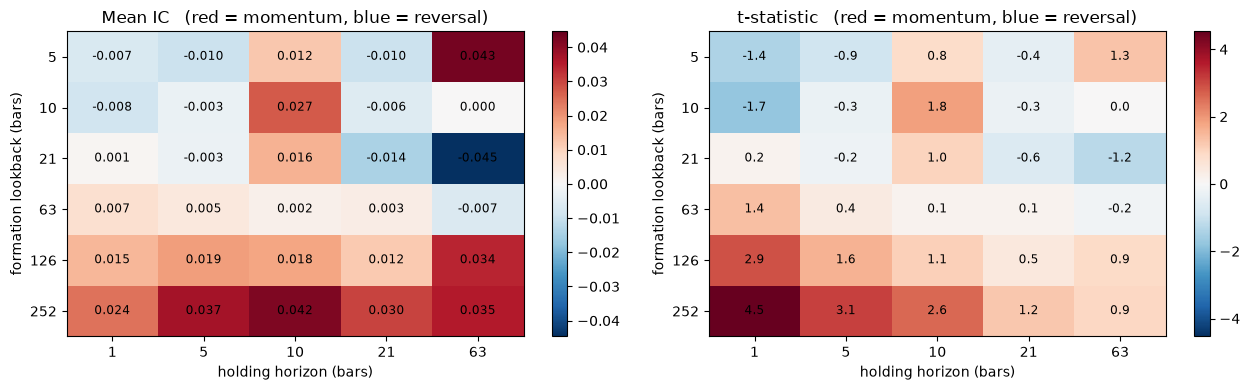

4 of 30 cells reach |t| > 2.
If that number is 0, this universe/period does not support either effect and no amount of backtesting will change that.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title, fmt in [
    (axes[0], mean_ic, 'Mean IC', '{:.3f}'),
    (axes[1], t_ic, 't-statistic', '{:.1f}'),
]:
    lim = np.nanmax(np.abs(data.to_numpy()))
    im = ax.imshow(data.to_numpy(), cmap='RdBu_r', vmin=-lim, vmax=lim,
                   aspect='auto')
    ax.set_xticks(range(len(data.columns)), data.columns)
    ax.set_yticks(range(len(data.index)), data.index)
    ax.set_xlabel('holding horizon (bars)')
    ax.set_ylabel('formation lookback (bars)')
    ax.set_title(f'{title}   (red = momentum, blue = reversal)')
    ax.grid(False)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt.format(v), ha='center', va='center',
                        fontsize=8.5)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

sig_cells = (t_ic.abs() > 2).sum().sum()
print(f'{sig_cells} of {t_ic.size} cells reach |t| > 2.')
print('If that number is 0, this universe/period does not support either',
      'effect and no amount of backtesting will change that.')

strongest cell: lookback=252, horizon=1 -> momentum
  mean IC=+0.0241 t=+4.53

n_obs       3931.0000
mean_ic        0.0241
std_ic         0.3329
t_stat         4.5346
p_value        0.0000
ir             0.0723
hit_rate       0.5396


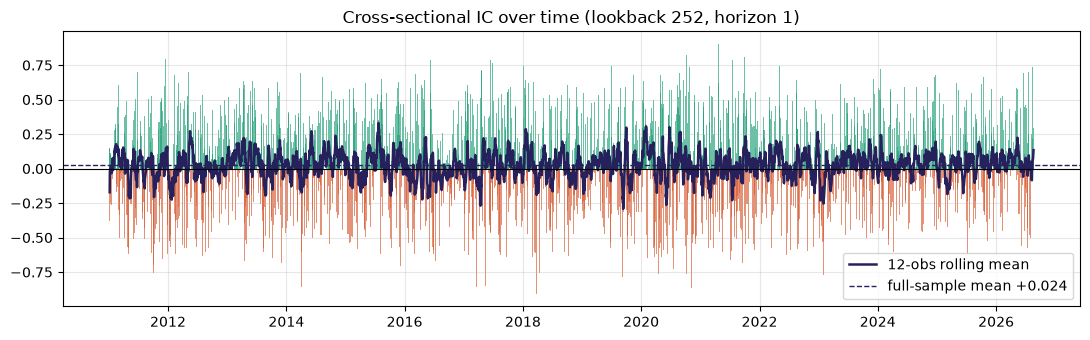

In [7]:
# Zoom in on the strongest cell and look at the signal's stability over time.
# A signal that works only in one regime is not the same as one that works.
flat = t_ic.stack()
best_lb, best_h = flat.abs().idxmax()
direction = 'momentum' if mean_ic.loc[best_lb, best_h] > 0 else 'reversal'
print(f'strongest cell: lookback={best_lb}, horizon={best_h} -> {direction}')
print(f'  mean IC={mean_ic.loc[best_lb, best_h]:+.4f}',
      f't={t_ic.loc[best_lb, best_h]:+.2f}')
print()

sig = trailing_signal(panel, int(best_lb), skip=0)
fwd = forward_returns(panel, int(best_h))
ic_ts = information_coefficient(sig, fwd, step=int(best_h))
print(ic_summary(ic_ts).round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(ic_ts.index, ic_ts.values, width=max(3, int(best_h)),
       color=np.where(ic_ts.values > 0, '#1D9E75', '#D85A30'), alpha=0.65)
roll = ic_ts.rolling(12, min_periods=4).mean()
ax.plot(roll.index, roll.values, color='#26215C', lw=1.8,
        label='12-obs rolling mean')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(ic_ts.mean(), color='#26215C', ls='--', lw=1,
           label=f'full-sample mean {ic_ts.mean():+.3f}')
ax.set_title(f'Cross-sectional IC over time (lookback {best_lb}, horizon {best_h})')
ax.legend(); plt.tight_layout(); plt.show()

### Write the hypothesis down

Before touching strategy code, state it explicitly. Writing it down is what
makes it falsifiable later, and stops you from quietly redefining success once
you see the equity curve.

> **H1.** In this universe, ranking constituents by trailing return over roughly
> the window identified above predicts their relative forward returns over a
> comparable horizon, with a positive mean IC that is stable in sign across
> sub-periods rather than concentrated in one regime.
>
> **Implication.** A long-only strategy holding the top-ranked subset, rebalanced
> at roughly the holding horizon, should earn a positive risk-adjusted return
> *after realistic costs*.
>
> **What would falsify it.** Mean IC indistinguishable from zero; IC sign that
> flips between sub-periods; or an edge that survives on paper but not after
> costs and a one-bar execution delay.

---
## 3. Strategies

Each of these is a few lines because the interface carries the weight. Note
that `TrendFilter` and `Composite` *wrap* other strategies — composition works
precisely because every strategy speaks in fractions of equity.

Four families beyond plain relative-strength momentum:

- **`PairsTrading`** — market-neutral stat-arb on the log-price spread of the
  most correlated pairs. Long/short, not long-only, so it should behave
  differently from everything else here in a drawdown.
- **`MultiFactorCrossSectional`** — blends momentum, low-vol, and reversal into
  one cross-sectional score, since fundamentals aren't available from a
  price-only panel.
- **`CalendarSeasonality`** — invested only in the turn-of-month window, flat
  the rest of the month. It needs a rebalance cadence finer than the others to
  express its logic at all, handled below.
- **`RiskParityAllocation`** — equal risk contribution across the whole
  universe from the trailing covariance matrix, not just inverse vol.

In [8]:
LB, HOLD = int(best_lb), int(best_h)
REBAL = {1: 'D', 5: 'W', 10: 'W', 21: 'M', 63: 'Q'}.get(HOLD, 'M')
print(f'using lookback={LB}, rebalance={REBAL!r}')

momentum = CrossSectionalMomentum(lookback=LB, skip=5, top_n=5)

strategies = {
    'benchmark_ew':   EqualWeightBuyHold(),
    'momentum':       momentum,
    'momentum_rank':  CrossSectionalMomentum(lookback=LB, skip=5, top_n=5,
                                             weighting='rank'),
    'momentum_ivol':  InverseVolWeighted(momentum, vol_lookback=63),
    'dual_momentum':  TrendFilter(momentum, lookback=200),
    'trend_only':     TimeSeriesMomentum(lookback=200),
    'reversal':       ShortHorizonReversal(lookback=5, top_n=4, min_z=1.0),
    'blend_60_40':    Composite([(momentum, 0.6),
                                 (TimeSeriesMomentum(lookback=200), 0.4)]),
    'pairs':          PairsTrading(formation=126, z_window=21, entry_z=1.5,
                                   n_pairs=6),
    'multifactor':    MultiFactorCrossSectional(top_n=5),
    'calendar':       CalendarSeasonality(pre_days=3, post_days=3),
    'risk_parity':    RiskParityAllocation(cov_lookback=126),
}

# Calendar only expresses its logic under sub-monthly rebalancing -- monthly
# decision bars land inside its window almost every time (see the class
# docstring). Everything else uses the IC-selected cadence from above.
REBAL_OVERRIDE = {'calendar': 'W'}

for name, s in strategies.items():
    print(f'  {name:16s} min_history={s.min_history:4d}  ({s.name})')

using lookback=252, rebalance='D'
  benchmark_ew     min_history=   2  (equal_weight)
  momentum         min_history= 259  (xsmom_252_5_5)
  momentum_rank    min_history= 259  (xsmom_252_5_5)
  momentum_ivol    min_history= 259  (xsmom_252_5_5+ivol)
  dual_momentum    min_history= 259  (xsmom_252_5_5+trend200)
  trend_only       min_history= 202  (tsmom_200)
  reversal         min_history=  70  (revert_5_4)
  blend_60_40      min_history= 259  (composite)
  pairs            min_history= 128  (pairs_126_21_1.5)
  multifactor      min_history= 133  (multifactor_5)
  calendar         min_history=   2  (calendar_tom_3_3)
  risk_parity      min_history= 128  (riskparity_126)


In [9]:
GATE = dict(target_vol=0.12, max_weight=0.30, max_gross=1.0, max_drawdown=0.25)
COSTS = CostModel(slippage_bps=5.0, commission_bps=0.0, sell_fee_bps=0.8)
EXEC = ExecutionConfig(delay_bars=1, price='close', allow_fractional=True)

def run(strategy, gate_kwargs=GATE, costs=COSTS, execution=EXEC,
        rebalance=None, data=None):
    """One place that builds a backtest, so comparisons stay apples-to-apples."""
    return Backtester(
        panel=data if data is not None else panel,
        strategy=strategy,
        risk_gate=RiskGate(**gate_kwargs) if gate_kwargs else None,
        cost_model=costs,
        execution=execution,
        rebalance=rebalance or REBAL,
        initial_equity=INITIAL_EQUITY,
    ).run()

results = {name: run(s, rebalance=REBAL_OVERRIDE.get(name, REBAL))
           for name, s in strategies.items()}
table = compare(results)
cols = ['cagr', 'ann_vol', 'sharpe', 'sortino', 'max_drawdown', 'calmar',
        'turnover_ann', 'cost_drag', 'avg_exposure', 'n_trades']
table[cols].sort_values('sharpe', ascending=False).round(3)

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,turnover_ann,cost_drag,avg_exposure,n_trades
benchmark_ew,0.075,0.111,0.701,0.871,-0.219,0.341,1.909,0.030,0.899,111365.0
blend_60_40,0.072,0.118,0.647,0.795,-0.195,0.370,27.306,0.416,0.813,69137.0
momentum,0.074,0.125,0.634,0.799,-0.188,0.393,28.104,0.440,0.758,20613.0
momentum_rank,0.074,0.126,0.634,0.815,-0.181,0.410,28.302,0.437,0.720,20633.0
trend_only,0.062,0.104,0.632,0.764,-0.174,0.359,27.474,0.391,0.860,70391.0
dual_momentum,0.068,0.118,0.613,0.771,-0.180,0.377,29.277,0.439,0.740,19532.0
momentum_ivol,0.069,0.123,0.603,0.760,-0.202,0.342,32.213,0.476,0.781,20698.0
risk_parity,0.057,0.116,0.534,0.653,-0.243,0.233,15.306,0.278,0.829,87040.0
calendar,0.006,0.052,0.132,0.073,-0.142,0.039,18.716,0.167,0.178,10030.0
multifactor,0.005,0.107,0.098,0.113,-0.255,0.019,80.368,0.887,0.717,19861.0


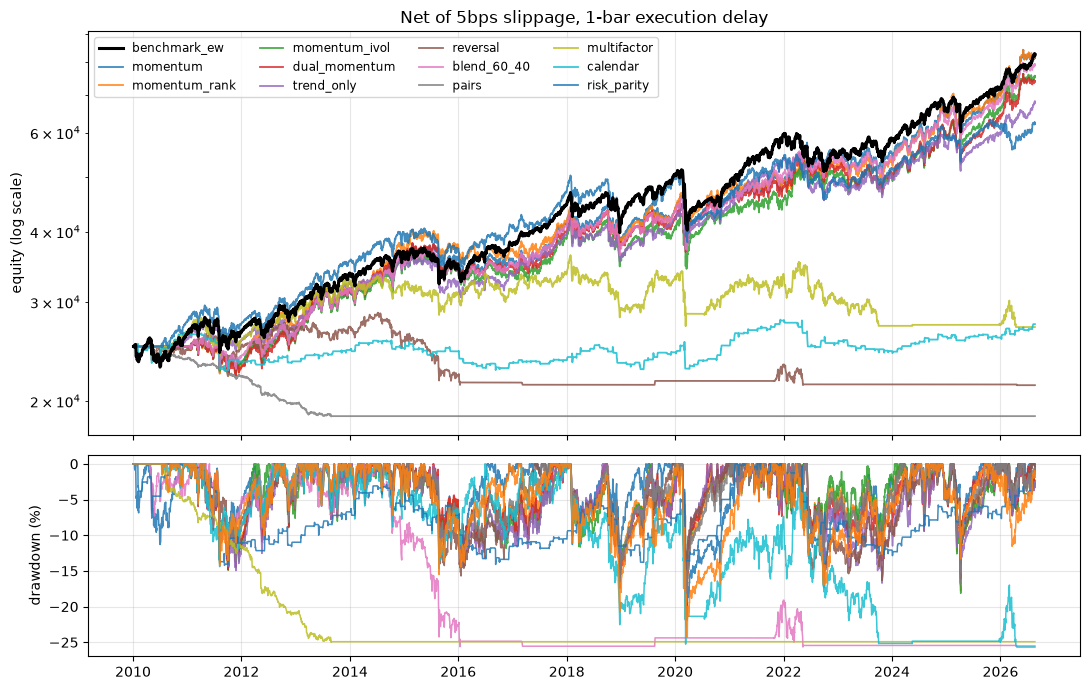

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
for name, res in results.items():
    style = dict(lw=2.2, color='black', zorder=5) if name == 'benchmark_ew' \
        else dict(lw=1.3, alpha=0.85)
    ax1.plot(res.equity.index, res.equity.values, label=name, **style)
    ax2.plot(res.equity.index, res.drawdown().values * 100, lw=1.1, alpha=0.85)
ax1.set_yscale('log')
ax1.set_ylabel('equity (log scale)')
ax1.set_title(f'Net of {COSTS.slippage_bps:.0f}bps slippage, '
              f'{EXEC.delay_bars}-bar execution delay')
ax1.legend(ncol=4, fontsize=8.5)
ax2.set_ylabel('drawdown (%)'); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

---
## 4. Beyond price: fundamentals, macro, corporate filings, options

Everything above is a pure function of price. Four more data types plug
into the exact same `Strategy` protocol -- `target_weights` just grows
three more optional parameters (`fundamentals`, `macros`, `corps`,
`options`), all `None` by default, so nothing above this cell changes:

- **`FundamentalsPanel`** (`qbt/fundamentals.py`) -- per-symbol financial-
  statement ratios, keyed by filing date.
- **`MacrosPanel`** (`qbt/macro.py`) -- economy-wide indicators (rates,
  CPI, ...), no symbol axis: every name in the universe sees the same
  reading.
- **`CorpsPanel`** (`qbt/corporate.py`) -- filing cadence and insider-
  trading activity, derived from SEC EDGAR (free, no API key).
- **`OptionsPanel`** (`qbt/options.py`) -- implied-vol and put/call-ratio
  indicators derived from options chains.

All four enforce the same look-ahead firewall as `PricePanel`:
`.as_of(date)` returns a copy structurally incapable of holding a row
from after `date`, and the backtester truncates every one of them before
every decision, the same way it already does for price.

**Read this before trusting any number below.** This block is
all-or-nothing: it fetches fundamentals (FMP), macro (FRED), filings
(SEC) and options together, and if *any* one raises, all four fall back
to synthetic stand-ins. FMP and FRED need registered API keys the way
price data does not, so a missing FMP key alone sends the macro panel
to synthetic even when FRED is configured. The cell prints which it
used -- read that line before reading the tables.

The stand-ins carry *no* deliberately embedded predictive structure,
unlike `SyntheticRepository`'s price data. They exist to prove the
machinery runs end to end -- point-in-time joins, strategy wiring,
backtest execution -- not to demonstrate an edge.

In [11]:
def _synthetic_fundamentals(panel, seed=11):
    """Quarterly P/E per symbol, released ~45 days after quarter end --
    the same fallback lag qbt/fundamentals.py uses when a provider has no
    true filing date. Structure is invented; useful for exercising the
    machinery, not for drawing conclusions."""
    rng = np.random.default_rng(seed)
    period_ends = pd.date_range(panel.dates[0], panel.dates[-1], freq='QE')
    rows = []
    for sym in panel.symbols:
        level = rng.uniform(10, 30)
        for pe in period_ends:
            level = float(np.clip(level + rng.normal(0, 1.5), 3, 60))
            rows.append((sym, 'ratios_pe_ratio', pe, pe + pd.Timedelta(days=45),
                        level))
    frame = pd.DataFrame(rows, columns=['symbol', 'metric', 'period_end',
                                        'as_of_date', 'value'])
    return FundamentalsPanel(frame=frame)


def _synthetic_macros(panel, seed=12):
    """Monthly policy-rate-like series, economy-wide -- no symbol axis."""
    rng = np.random.default_rng(seed)
    period_ends = pd.date_range(panel.dates[0], panel.dates[-1], freq='ME')
    level, rows = 2.0, []
    for pe in period_ends:
        level = float(np.clip(level + rng.normal(0, 0.15), 0.0, 6.0))
        rows.append(('fed_funds_rate', pe, pe + pd.Timedelta(days=3), level))
    frame = pd.DataFrame(rows, columns=['metric', 'period_end', 'as_of_date',
                                        'value'])
    return MacrosPanel(frame=frame)


def _synthetic_corps(panel, seed=13):
    """Sparse 8-K filings and insider buying, one random event stream per
    symbol -- the trailing-window count/sum convention qbt/corporate.py
    actually produces (values step up at each event, hold flat between).
    Every event here is a buy (increments insider_buy_count_90d and adds
    to insider_net_shares_90d), which is what InsiderEventDrift actually
    requires -- it reads insider_buy_count_90d specifically, not just the
    net-shares figure, to detect a fresh transaction."""
    rng = np.random.default_rng(seed)
    rows = []
    for sym in panel.symbols:
        n_events = int(rng.integers(3, 10))
        event_dates = pd.DatetimeIndex(sorted(
            rng.choice(panel.dates[60:], size=n_events, replace=False)))
        count8k, buy_count, net_shares = 0, 0, 0.0
        for d in event_dates:
            count8k += 1
            buy_count += 1
            net_shares += float(rng.uniform(1_000, 8_000))
            rows.append((sym, 'filed_8k_count_90d', d, d, float(count8k)))
            rows.append((sym, 'insider_buy_count_90d', d, d, float(buy_count)))
            rows.append((sym, 'insider_net_shares_90d', d, d, net_shares))
    frame = pd.DataFrame(rows, columns=['symbol', 'metric', 'period_end',
                                        'as_of_date', 'value'])
    return CorpsPanel(frame=frame)


EVENT_WINDOW_BARS = 756   # ~3 trading years


def _synthetic_options(panel, seed=14, lookback=EVENT_WINDOW_BARS):
    """Daily options-stress indicators for the most recent `lookback`
    trading days only -- deliberately not the whole panel history. Real
    free options data only gives you today's snapshot (see the module
    docstring in qbt/options.py): an archive only covers however long
    you've actually been running fetch_snapshot() for, a recent window,
    not years of backfilled history. This mirrors that honestly rather
    than pretending otherwise -- and it's also why the event-strategy
    backtest below only walks the same recent window: daily rebalancing
    over the full multi-year history is the same slow you already saw
    in section 5, compounded by scanning this panel on every bar."""
    rng = np.random.default_rng(seed)
    recent_dates = panel.dates[-lookback:]
    n, t = len(panel.symbols), len(recent_dates)
    iv = np.clip(0.25 + np.cumsum(rng.normal(0, 0.002, size=(n, t)), axis=1),
                0.10, 0.80)
    pcr = np.clip(0.9 + rng.normal(0, 0.15, size=(n, t)), 0.2, 3.0)
    spikes = rng.random((n, t)) < 0.01
    iv = np.where(spikes, iv + 0.25, iv)
    pcr = np.where(spikes, pcr + 1.2, pcr)
    frames = []
    for arr, metric in ((iv, 'iv_atm_near'), (pcr, 'put_call_volume_ratio')):
        wide = pd.DataFrame(arr.T, index=recent_dates, columns=panel.symbols)
        long = wide.reset_index(names='as_of_date').melt(
            id_vars='as_of_date', var_name='symbol', value_name='value')
        long['metric'] = metric
        long['period_end'] = long['as_of_date']
        frames.append(long)
    frame = pd.concat(frames, ignore_index=True)[
        ['symbol', 'metric', 'period_end', 'as_of_date', 'value']]
    return OptionsPanel(frame=frame)


def _panel_or_stand_in(label, fetch_live, build_stand_in):
    """Try one panel's live fetch; fall back to its stand-in alone.

    Per panel, deliberately. These four have independent providers and
    independent credentials, so one wrapping try/except made them share a
    fate they don't actually share: a missing FMP key sent the *macro*
    panel to synthetic even with FRED configured and working. Each one now
    stands or falls on its own, and the source is reported rather than
    inferred.
    """
    if not USE_OPENBB:
        return build_stand_in(), 'stand-in (USE_OPENBB=False)'
    try:
        return fetch_live(), 'LIVE'
    except Exception as exc:
        first = str(exc).strip().splitlines()[0][:88] if str(exc).strip() else ''
        return build_stand_in(), f'stand-in ({type(exc).__name__}: {first})'


fundamentals, _src_f = _panel_or_stand_in(
    'fundamentals',
    lambda: FundamentalsRepository(provider='fmp').fetch(UNIVERSE, START, END),
    lambda: _synthetic_fundamentals(panel))
macros, _src_m = _panel_or_stand_in(
    'macros',
    lambda: MacrosRepository().fetch(START, END),
    lambda: _synthetic_macros(panel))
corps, _src_c = _panel_or_stand_in(
    'corps',
    lambda: CorpsRepository().fetch(UNIVERSE, START, END),   # free, no key
    lambda: _synthetic_corps(panel))
# Free options providers only return today's live chain -- there is no
# multi-year history to pull in one shot (see qbt/options.py).
# fetch_snapshot() archives today's reading; running this cell daily builds
# a real point-in-time history over time.
options_panel, _src_o = _panel_or_stand_in(
    'options',
    lambda: OptionsRepository().fetch_snapshot(UNIVERSE),
    lambda: _synthetic_options(panel))

print('Which panels are real, and which are stand-ins:')
for _name, _p, _src in [('fundamentals', fundamentals, _src_f),
                        ('macros', macros, _src_m),
                        ('corps', corps, _src_c),
                        ('options', options_panel, _src_o)]:
    print(f'  {_name:12s} {_src:52s} {_p.describe()}')
print()
print('Anything marked stand-in below carries no embedded predictive',
      'structure -- do not read an edge off it.')


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached entries to download, estimated download time: 0 seconds.


Found 0 total filings and 0 uncached en

Which panels are real, and which are stand-ins:
  fundamentals stand-in (OpenBBError: [Error] -> Missing credential 'fmp_api_key'. Check https://financialmodelingprep.com to ) FundamentalsPanel(30 symbols, 1 metrics, 1980 filings, 2010-05-15 to 2026-08-14)
  macros       LIVE                                                 MacrosPanel(10 indicators, 17752 observations, 2010-01-05 to 2026-08-21)
  corps        LIVE                                                 CorpsPanel(14 symbols, 6 metrics, 1408 events, 2009-11-16 to 2026-08-18)
  options      LIVE                                                 OptionsPanel(30 symbols, 5 metrics, 150 readings, 2026-08-21 to 2026-08-21)

Anything marked stand-in below carries no embedded predictive structure -- do not read an edge off it.


### The firewall, demonstrated

Same property as `PricePanel.as_of` -- worth seeing directly rather than
taking on faith.

In [12]:
mid = panel.dates[len(panel) // 2]
print(f'as of {mid.date()}:')
print()
print('fundamentals known so far (P/E per symbol), first 5:')
print(fundamentals.snapshot(mid).head())
print()
print('macro known so far:')
print(macros.snapshot(mid))
print()
leak_free = (fundamentals.as_of(mid).frame['as_of_date'] <= mid).all()
print(f'fundamentals.as_of({mid.date()}) contains nothing filed later: {leak_free}')

as of 2018-04-26:

fundamentals known so far (P/E per symbol), first 5:
metric  ratios_pe_ratio
symbol                 
AAPL          13.224789
CSCO          26.698357
CVX            8.420115
DBC           15.082345
EEM           30.853489

macro known so far:
metric
real_gdp             19882.352
fed_funds_rate           1.510
unemployment_rate        4.000
core_cpi               256.271
cpi                    249.577
m2_money_supply      14014.500
vix                     17.840
yield_10y                3.030
yield_2y                 2.490
yield_3m                 1.850
dtype: float64

fundamentals.as_of(2018-04-26) contains nothing filed later: True


### Fundamentals and macro as filters

The recommended role for slow-moving data: not a standalone daily
signal -- a quarterly P/E doesn't move fast enough to explain next
week's return -- but a *filter* on top of a price-based strategy that
already works. `FundamentalsValueFilter` blocks picks that fail a
valuation screen; `MacroRegimeFilter` de-risks the whole book in an
unfavourable regime. Both wrap any strategy the same way `TrendFilter`
already does in section 3, and both are no-ops (pass the inner
strategy's weights straight through) if the corresponding panel is
absent -- a missing keyword argument should never silently flatten a
whole book.

In [13]:
value_screen = FundamentalsValueFilter(momentum, metric='ratios_pe_ratio',
                                       max_value=25.0)
# 2.75 is chosen to actually bind against this synthetic series (check
# macros.snapshot(...) over time if you change the seed above) -- pick a
# level from real data, not this number, once USE_OPENBB is on.
regime_gate = MacroRegimeFilter(momentum, metric='fed_funds_rate',
                                max_level=2.75)

filter_strategies = {
    'momentum':             momentum,   # baseline, same object as section 3
    'momentum_cheap_only':  value_screen,
    'momentum_macro_gated': regime_gate,
}
filter_results = {
    name: Backtester(
        panel=panel, strategy=s, fundamentals=fundamentals, macros=macros,
        risk_gate=RiskGate(**GATE), cost_model=COSTS, execution=EXEC,
        rebalance=REBAL, initial_equity=INITIAL_EQUITY,
    ).run()
    for name, s in filter_strategies.items()
}
compare(filter_results)[cols].round(3)

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,turnover_ann,cost_drag,avg_exposure,n_trades
momentum,0.074,0.125,0.634,0.799,-0.188,0.393,28.104,0.440,0.758,20613.0
momentum_cheap_only,0.068,0.105,0.681,0.857,-0.184,0.372,19.270,0.297,0.576,13628.0
momentum_macro_gated,0.049,0.109,0.495,0.543,-0.188,0.262,20.597,0.268,0.573,15567.0


### Two strategies built for this data specifically

- **`InsiderEventDrift`** -- long fresh insider buying that follows a
  recent 8-K, held for a short drift window. A pure function of today's
  data with no held-position bookkeeping: it compares today's corporate-
  filings snapshot against the snapshot from `drift_days` ago, so the
  position enters on the event and exits on its own once the event ages
  out of the comparison window -- same "unwinds on its own" discipline
  `PairsTrading` uses in section 3.
- **`OptionsMeanReversion`** -- contrarian: buys names where options-
  implied fear (elevated IV, heavy put buying) is most stretched
  relative to their own recent history. The one strategy in this
  package genuinely built for a daily/weekly horizon, since options
  data is the one new data source that updates daily. **Real
  caveat**: free options-chain providers only return today's live
  chain -- there's no historical endpoint. A real backtest of this
  strategy needs daily snapshots archived yourself via
  `OptionsRepository.fetch_snapshot()`; what runs below is against the
  synthetic stand-in only.

Both need daily rebalancing to express entry/exit at all -- same reason
`CalendarSeasonality` needed a sub-monthly override above, and daily
rebalancing over the *full* history is the same slow it was in section 5
-- worse here, since it also means scanning the options/corps panels on
every single bar. `event_window` below matches the recent slice
`_synthetic_options` actually populated, which is both faster and the
honest scope for this data anyway.

In [14]:
event_window = panel.tail(EVENT_WINDOW_BARS)
event_results = {
    'insider_event_drift': Backtester(
        panel=event_window, strategy=InsiderEventDrift(drift_days=10, top_n=5),
        corps=corps, risk_gate=RiskGate(**GATE), cost_model=COSTS,
        execution=EXEC, rebalance='D', initial_equity=INITIAL_EQUITY,
    ).run(),
    'options_mean_reversion': Backtester(
        panel=event_window,
        strategy=OptionsMeanReversion(iv_window=20, top_n=5, min_z=1.0),
        options=options_panel, risk_gate=RiskGate(**GATE), cost_model=COSTS,
        execution=EXEC, rebalance='D', initial_equity=INITIAL_EQUITY,
    ).run(),
}
compare(event_results)[cols].round(3)

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,turnover_ann,cost_drag,avg_exposure,n_trades
insider_event_drift,-0.003,0.012,-0.274,-0.077,-0.023,-0.145,0.819,0.001,0.01,28.0
options_mean_reversion,0.000,0.000,NaN,NaN,0.000,NaN,0.000,0.000,0.00,0.0


---
## 5. Why execution timing is not a detail

The single most common way a backtest invents returns: compute a signal from
bar *T*'s close, then fill at bar *T*'s close. You cannot observe a closing
price and simultaneously trade on it.

The engine defaults to `delay_bars=1` for this reason, and refuses
`delay_bars=0` combined with `price='open'` outright, since that combination
fills *before* the information exists. Below is the same strategy under both
assumptions. The gap is the size of the lie.

In [15]:
# Daily rebalancing over the full history is slow and adds nothing here,
# so this demonstration uses the last five years.
recent = panel.tail(1260)
fast = ShortHorizonReversal(lookback=3, top_n=4, min_z=0.5)
timing = {}
for label, cfg in {
    'same-close fill (delay=0)': ExecutionConfig(delay_bars=0, price='close'),
    'next-bar fill (delay=1)':   ExecutionConfig(delay_bars=1, price='close'),
    'two-bar fill (delay=2)':    ExecutionConfig(delay_bars=2, price='close'),
}.items():
    timing[label] = run(fast, execution=cfg, rebalance='D', data=recent,
                        gate_kwargs=dict(target_vol=0.12, max_drawdown=None))

t_tbl = compare(timing)[['cagr', 'ann_vol', 'sharpe', 'max_drawdown', 'n_trades']]
print(t_tbl.round(3).to_string())
print()
sr = t_tbl['sharpe']
print(f"Sharpe collapses from {sr.iloc[0]:+.2f} to {sr.iloc[1]:+.2f} "
      f"purely from honest fill timing.")
print('A short-horizon signal is where this bites hardest, because the effect',
      'it harvests decays within a bar or two.')

                            cagr  ann_vol  sharpe  max_drawdown  n_trades
same-close fill (delay=0) -0.047    0.113  -0.366        -0.332    6340.0
next-bar fill (delay=1)   -0.026    0.116  -0.173        -0.324    6337.0
two-bar fill (delay=2)    -0.070    0.118  -0.559        -0.467    6324.0

Sharpe collapses from -0.37 to -0.17 purely from honest fill timing.
A short-horizon signal is where this bites hardest, because the effect it harvests decays within a bar or two.


---
## 6. The risk gate

The gate is the only component with authority to reduce exposure, and it
records why. That log is the artefact you want when reviewing a bad month —
"why was I flat in March" should be answerable by reading, not reconstructing.

Volatility targeting rarely raises returns. It compresses the *distribution*,
which is what makes a strategy survivable by a human who has to watch it.

In [ ]:
variants = {
    'no gate':        None,
    'caps only':      dict(target_vol=None, max_weight=0.30, max_gross=1.0,
                           max_drawdown=None),
    'vol target 12%': dict(target_vol=0.12, max_weight=0.30, max_gross=1.0,
                           max_drawdown=None),
    'vol target 8%':  dict(target_vol=0.08, max_weight=0.30, max_gross=1.0,
                           max_drawdown=None),
    'full gate':      GATE,
}
gate_results = {k: run(momentum, gate_kwargs=v) for k, v in variants.items()}
compare(gate_results)[['cagr', 'ann_vol', 'sharpe', 'max_drawdown', 'calmar',
                       'avg_exposure', 'time_invested']].round(3)

In [ ]:
full = gate_results['full gate']
audit = full.audit
print(f'{len(audit)} rebalance decisions logged\n')
print('most recent:')
print(audit.tail(5).to_string())
print()
print('halted on', int(audit['halted'].sum()), 'rebalances')
print()
print('most common reasons:')
reasons = (audit['notes'].astype(str).str.split('; ')
           .explode().str.replace(r'[\d.]+', 'N', regex=True))
print(reasons[reasons != ''].value_counts().head(6).to_string())

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(full.exposure.index, full.exposure.values, lw=1.0, color='#185FA5')
ax1.fill_between(full.exposure.index, 0, full.exposure.values, alpha=0.18,
                 color='#185FA5')
ax1.set_ylabel('gross exposure'); ax1.set_title('Gate output over time')
if audit['halted'].any():
    for d in audit.index[audit['halted']]:
        ax1.axvline(d, color='#E24B4A', alpha=0.28, lw=1.1)
    ax1.plot([], [], color='#E24B4A', alpha=0.6, label='drawdown breaker active')
    ax1.legend(fontsize=9)
ax2.plot(audit.index, audit['forecast_vol'] * 100, lw=1.2,
         label='forecast vol', color='#BA7517')
ax2.axhline(12, ls='--', lw=1, color='black', label='target 12%')
ax2.set_ylabel('annualised vol (%)'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

rz = full.returns[full.returns != 0]
print(f'realised vol {rz.std() * np.sqrt(252):.2%} against a 12% target')
print(f'kurtosis {rz.kurtosis():.2f}  (vol targeting shrinks the body,',
      'it does not remove tails)')

---
## 7. Costs

Zero commission is not zero cost. Half the spread, market impact, and
regulatory fees on sales are all real, and they scale with turnover. The useful
question is not "what is my edge" but "at what cost level does my edge
disappear" — because that number tells you how much execution quality you can
afford to be wrong about.

In [ ]:
rows = []
for slip in [0, 2, 5, 10, 20, 40]:
    for strat_name in ['momentum', 'reversal', 'dual_momentum']:
        r = run(strategies[strat_name], costs=CostModel(slippage_bps=slip),
                rebalance='M')  # fixed cadence keeps turnover comparable
        s = r.summary()
        rows.append({'slippage_bps': slip, 'strategy': strat_name,
                     'cagr': s['cagr'], 'sharpe': s['sharpe'],
                     'turnover_ann': s['turnover_ann']})
cost_df = pd.DataFrame(rows)
pivot = cost_df.pivot(index='slippage_bps', columns='strategy', values='sharpe')
print('Sharpe by slippage assumption:')
print(pivot.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker='o', label=col)
ax.axhline(0, color='black', lw=0.9)
ax.set_xlabel('assumed slippage (bps per side)'); ax.set_ylabel('Sharpe')
ax.set_title('Where does the edge die?'); ax.legend()
plt.tight_layout(); plt.show()

print()
print('annualised turnover:')
print(cost_df.groupby('strategy')['turnover_ann'].first().round(2).to_string())
print('\nHigh-turnover strategies are bets on your execution quality as much',
      'as on your signal.')

---
## 8. Parameter sweeps and the multiple-testing problem

Search enough configurations and the best one looks good *by construction*.
With N independent trials of a genuinely worthless strategy, the expected
maximum Sharpe is roughly

$$\mathbb{E}[\max SR] \approx \sigma_{SR}\left[(1-\gamma)Z^{-1}\!\left(1-\tfrac{1}{N}\right) + \gamma Z^{-1}\!\left(1-\tfrac{1}{Ne}\right)\right]$$

So the honest reading of a sweep is not "the best cell", it is:

1. Does the best cell clear the expected-max-under-null threshold?
2. Is the surface **smooth**? A Sharpe that collapses when you nudge a lookback
   by 10% is a coincidence with good marketing.
3. What does the *median* cell look like? That is closer to what you should
   expect to live with than the maximum.

In [ ]:
def evaluate(lookback, top_n, skip):
    r = run(CrossSectionalMomentum(lookback=lookback, skip=skip, top_n=top_n),
            rebalance='M')
    s = r.summary()
    return {'sharpe': s['sharpe'], 'cagr': s['cagr'],
            'max_dd': s['max_drawdown'], 'turnover': s['turnover_ann']}


sweep = ParameterSweep(
    grid={'lookback': [21, 42, 63, 126, 189, 252],
          'top_n': [3, 5, 8],
          'skip': [0, 5]},
    evaluate=evaluate,
)
sw = sweep.run()
print(f'{len(sw)} configurations evaluated\n')
print('top 5 by Sharpe:')
print(sw.nlargest(5, 'sharpe').round(3).to_string(index=False))
print('\nbottom 3:')
print(sw.nsmallest(3, 'sharpe').round(3).to_string(index=False))
print()
stab = ParameterSweep.stability(sw, 'sharpe')
print('distribution:', stab.round(3).to_dict())

In [ ]:
best = float(sw['sharpe'].max())
dispersion = float(sw['sharpe'].std(ddof=1))
hc = sharpe_haircut(best, n_trials=len(sw), sharpe_dispersion=dispersion)

print(f'best observed Sharpe        {hc["observed_sharpe"]:+.3f}')
print(f'configurations searched     {hc["n_trials"]}')
print(f'cross-trial dispersion      {dispersion:.3f}')
print(f'expected max under null     {hc["expected_max_under_null"]:+.3f}')
print(f'excess over null            {hc["excess"]:+.3f}')
print(f'survives the haircut        {hc["survives"]}')
print()
if not hc['survives']:
    print('The winner is within what pure search effort produces on noise.')
    print('That is not a reason to tune harder; it is evidence of no edge here.')
else:
    print('Clears the threshold, which is necessary but not sufficient --',
          'confirm out of sample below.')

fig, ax = plt.subplots(figsize=(10, 4))
for (tn, sk), grp in sw.groupby(['top_n', 'skip']):
    g = grp.sort_values('lookback')
    ax.plot(g['lookback'], g['sharpe'], marker='o', ms=4,
            label=f'top_n={tn}, skip={sk}')
ax.axhline(hc['expected_max_under_null'], ls='--', color='#A32D2D',
           label='E[max Sharpe | no edge]')
ax.axhline(0, color='black', lw=0.9)
ax.set_xlabel('formation lookback (bars)'); ax.set_ylabel('Sharpe')
ax.set_title('Parameter surface -- look for a plateau, not a spike')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

---
## 9. Walk-forward

Pick parameters on a training window, evaluate on the window immediately after,
roll forward, repeat. Every test observation is genuinely out of sample with
respect to the choice that produced it.

Expect degradation. In-sample Sharpe well above out-of-sample is normal and
informative; the ratio between them is a rough measure of how much of your
in-sample result was fitting. What should worry you is *sign* instability across
folds — that means the effect is not there, and one fold happened to carry it.

In [ ]:
splits = walk_forward_splits(panel.dates, train_bars=1008, test_bars=378,
                             anchored=True)   # 4y train, 1.5y test
print(f'{len(splits)} folds\n')

CANDIDATES = [(lb, tn) for lb in (42, 63, 126, 252) for tn in (3, 8)]
fold_rows = []

for k, (train_idx, test_idx) in enumerate(splits, 1):
    train_panel = panel.as_of(train_idx[-1])

    scored = []
    for lb, tn in CANDIDATES:
        s = run(CrossSectionalMomentum(lookback=lb, skip=5, top_n=tn),
                data=train_panel, rebalance='M').summary()
        scored.append((s['sharpe'], lb, tn))
    is_sharpe, lb, tn = max(scored, key=lambda x: (x[0] if np.isfinite(x[0]) else -9))

    # Evaluate the chosen config on the test window only. History before the
    # window is still needed to warm the signal up, hence the full slice.
    oos_full = run(CrossSectionalMomentum(lookback=lb, skip=5, top_n=tn),
                   data=panel.as_of(test_idx[-1]), rebalance='M')
    oos_eq = oos_full.equity.loc[test_idx[0]:test_idx[-1]]
    oos_ret = oos_eq.pct_change(fill_method=None).dropna()
    oos_sharpe = (oos_ret.mean() / oos_ret.std() * np.sqrt(252)
                  if oos_ret.std() > 0 else np.nan)

    fold_rows.append({
        'fold': k,
        'train_end': train_idx[-1].date(),
        'test_end': test_idx[-1].date(),
        'picked_lb': lb, 'picked_top_n': tn,
        'is_sharpe': is_sharpe,
        'oos_sharpe': oos_sharpe,
        'oos_return': oos_eq.iloc[-1] / oos_eq.iloc[0] - 1,
    })

wf = pd.DataFrame(fold_rows)
print(wf.round(3).to_string(index=False))

In [ ]:
print(f"mean in-sample Sharpe      {wf['is_sharpe'].mean():+.3f}")
print(f"mean out-of-sample Sharpe  {wf['oos_sharpe'].mean():+.3f}")
deg = (wf['oos_sharpe'].mean() / wf['is_sharpe'].mean()
       if wf['is_sharpe'].mean() != 0 else np.nan)
print(f"retention ratio            {deg:.2f}")
print(f"folds with positive OOS    {int((wf['oos_sharpe'] > 0).sum())} / {len(wf)}")
print(f"parameter stability        lookback chosen: "
      f"{sorted(wf['picked_lb'].unique())}")
print()
if wf['picked_lb'].nunique() > len(wf) * 0.6:
    print('The optimiser picks a different lookback almost every fold, which',
          'means the surface is noise-dominated -- prefer a fixed, economically',
          'motivated parameter over a re-fitted one.')

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(wf))
ax.bar(x - 0.2, wf['is_sharpe'], 0.4, label='in-sample', color='#85B7EB')
ax.bar(x + 0.2, wf['oos_sharpe'], 0.4, label='out-of-sample', color='#185FA5')
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x, [f"F{r.fold}\n{r.test_end}" for r in wf.itertuples()],
              fontsize=8)
ax.set_ylabel('Sharpe'); ax.set_title('In-sample vs out-of-sample by fold')
ax.legend(); plt.tight_layout(); plt.show()

---
## 10. Live parity

The payoff. `LiveSignalRunner` takes the **same strategy object** and the **same
gate object** used above, points them at a panel whose last bar is today, and
emits order intents. There is no second sizing implementation to drift.

It deliberately stops at *intents*. Submitting them belongs to an order manager
with its own idempotency and reconciliation, behind a separate interface — which
is why you can run this cell against your real positions without risk of an
order escaping.

The assertion at the end is the parity test: the live path and a direct gate
call must produce bit-identical weights. Worth keeping in your actual test
suite, because it is the invariant the whole architecture rests on.

In [ ]:
CHOSEN = CrossSectionalMomentum(lookback=LB, skip=5, top_n=5)
LIVE_GATE = RiskGate(**GATE)

# A near-flat book rebalancing into a 5-name target is legitimately
# high-turnover, so the cap is permissive here; the guard is demonstrated
# separately below.
runner = LiveSignalRunner(
    strategy=CHOSEN,
    risk_gate=LIVE_GATE,
    min_trade_notional=10.0,
    allow_fractional=True,
    max_turnover=2.0,
    day_trade_ledger=DayTradeLedger(limit=3, equity_threshold=25_000),
)

# In production, read this from the broker every time. Never from memory:
# after a crash your in-process view of positions is a guess.
state = PortfolioState(
    cash=6_000.0,
    shares=pd.Series({panel.symbols[0]: 40.0, panel.symbols[3]: 25.0}),
    peak_equity=26_000.0,
)

plan = runner.plan(panel, state)
print(plan)
for w in plan.warnings:
    print('  WARNING:', w)
print()

# The same call under a deliberately tight cap: every order is scaled
# down by the same factor to fit, rather than the whole plan being
# withheld. A smaller version of the rebalance you asked for, not a
# position you didn't choose -- see the plan's own warning for exactly
# what got scaled and by how much.
guarded = LiveSignalRunner(strategy=CHOSEN, risk_gate=LIVE_GATE,
                          max_turnover=0.10)
gplan = guarded.plan(panel, state)
print(f'with a 10% turnover cap: {len(gplan.intents)} intents, '
      f'turnover={gplan.turnover:.1%}')
for w in gplan.warnings:
    print('  WARNING:', w)
print()
plan.to_frame().round(4)

In [ ]:
print('audit record (persist this append-only, alongside the fills):')
for k, v in plan.audit_record().items():
    print(f'  {k:>14s}: {v}')
print()
print('order payloads, broker-agnostic:')
for intent in plan.intents[:5]:
    print(' ', intent.to_payload())
print()
print('Map these onto the MCP server\'s order tool. Enumerate its tools at',
      'runtime rather than hard-coding names -- the schema is the server\'s to',
      'change, and a stale name fails at the worst possible moment. Attach your',
      'own client_order_id upstream so a retry cannot double-fill.')

In [ ]:
# Parity invariant: live path == direct gate call, exactly.
from qbt.risk import RiskContext

v = panel.as_of(panel.last_date())
prices = v.last_close()
equity = state.equity(prices)
ctx = RiskContext(
    date=v.last_date(), equity=equity,
    peak_equity=state.peak_equity or equity,
    prices=prices, returns=v.returns(), positions=state.shares,
    day_trades_remaining=3,
)
direct = RiskGate(**GATE).apply(CHOSEN.target_weights(v), ctx).weights
live_w = plan.target_weights.reindex(direct.index).fillna(0.0)

assert np.allclose(live_w.to_numpy(), direct.to_numpy(), atol=1e-12), \
    'live and backtest code paths diverged'
print('PASS: live runner and direct gate call produce identical weights')
print(f'      max abs difference {np.abs(live_w - direct).max():.2e}')

---
## 11. What this does not tell you

The engine is careful about the things it can be careful about. It cannot fix
these, and they dominate the gap between a backtest and a live P&L:

**Point-in-time data, partially.** Section 4 covers this properly now --
`FundamentalsPanel`/`MacrosPanel`/`CorpsPanel`/`OptionsPanel` all enforce the
same look-ahead firewall the price panel does. What's still unaddressed:
index membership changes and ticker reuse (a delisted-inclusive constituent
history is a separate, expensive problem -- see Survivorship below), and true
revision-aware fundamentals/macro data, since the free providers this
package uses only return the latest revised value, not what was known at the
time (see `qbt/macro.py`'s module docstring for the specifics).

**Survivorship.** Liquid ETFs mostly sidestep it. A single-stock universe does
not; you need a delisted-inclusive constituent history, which is the single
most expensive piece of a serious retail setup.

**Fill realism.** The cost model charges a fixed spread against the reference
price. It does not model partial fills, gaps through your price, a halt, or
impact that scales with your size against the book. At retail size in liquid
names this is a modest sin; in small caps it is a large one.

**Regime dependence.** Ten years of history contains a handful of independent
macro regimes, not 2,500 independent observations. Your effective sample size
for "does this survive a regime change" is closer to 3 than to 10.

**The thing the code cannot check.** Whether you will actually run it unchanged
through a 20% drawdown. That is the binding constraint on most retail systematic
trading, and no amount of engineering addresses it. Size the account so being
wrong is tuition.

### Suggested next steps

1. Compare against `USE_OPENBB = False`. The synthetic panel has momentum
   and reversal deliberately built in, so it is the control: a diagnostic
   that fires there and not on real data is measuring the generator.
2. Re-read the IC grid on real data **before** looking at any equity curve.
3. Add a `tests/` directory. The parity assertion above and the null test in
   `test_qbt.py` are the two that earn their keep.
4. Keep the audit frame from every run. It is the only thing that will let you
   distinguish "the strategy stopped working" from "I changed something".

---
## 12. Connecting to Robinhood

**The notebook does not place orders.** Notebooks have hidden state and
out-of-order execution: re-running a cell re-submits, and a kernel restart
loses the record of what was already sent. Execution lives in `run_cycle.py`,
a separate process with a write-ahead journal and crash recovery.

What the notebook *is* good for is the read side and the dry run. Below,
read-only broker access replaces the hypothetical `PortfolioState` with your
real positions, and `dry_run=True` shows you exactly what would be sent.

### The tool surface

The MCP server at `https://agent.robinhood.com/mcp/trading` exposes roughly:

| class | tools |
|---|---|
| read | `get_accounts`, `get_portfolio`, `get_equity_positions`, `get_equity_quotes`, `get_equity_orders`, `search` |
| watchlists | `get_watchlists`, `add_to_watchlist`, `update_watchlist` |
| trade | `review_equity_order`, `place_equity_order`, `cancel_equity_order` |

`RobinhoodMCPBroker` does not hard-code those names. It enumerates the
server's tools at connect time, binds capabilities by matching candidate
names, and resolves *argument* names from each tool's input schema -- so a
server that says `ticker` where you assumed `symbol` still works. If a
required capability is missing it raises at connect, not at the first order.

Run `broker.list_capabilities()` before anything else and read what your
server actually offers.

In [ ]:
import os

from qbt.broker import MockBroker, RobinhoodMCPBroker
from qbt.orders import AuditLog, ExecutionPolicy, OrderManager

USE_REAL_BROKER = False   # True requires `pip install mcp` and OAuth

if USE_REAL_BROKER:
    # OAuth is the piece to verify first. The simplest path is to let an
    # established client complete the handshake once, then reuse the token;
    # otherwise pass an mcp.client.auth.OAuthClientProvider as `auth=`.
    broker = RobinhoodMCPBroker(token=os.environ['ROBINHOOD_MCP_TOKEN'],
                               require_agentic=True)
    broker.connect()
    print(broker.list_capabilities().to_string(index=False))
else:
    # Offline stand-in: same protocol, models partial fills and rejections.
    broker = MockBroker(prices=panel.last_close(), cash=INITIAL_EQUITY,
                        positions=pd.Series(dtype=float), seed=0)
    broker.connect()

account = broker.get_account()
print(f'account   {account.account_id}  agentic={account.is_agentic}')
print(f'equity    {account.equity:,.2f}')
print(f'cash      {account.cash:,.2f}')
print(f'positions {len(account.positions)}')

In [ ]:
# Real positions replace the hypothetical state. This is the one thing the
# notebook genuinely gains from broker access.
live_state = PortfolioState(
    cash=account.cash,
    shares=account.positions.reindex(panel.symbols).fillna(0.0),
    # Seed the peak from current equity. Do NOT seed it from an unrelated
    # constant: if the account holds less than that number, the drawdown
    # breaker trips on the first cycle and the bot silently never trades.
    # In production, persist the true running peak across restarts.
    peak_equity=account.equity,
)
live_plan = LiveSignalRunner(strategy=CHOSEN, risk_gate=RiskGate(**GATE),
                            max_turnover=2.0).plan(panel, live_state)
print(live_plan)
live_plan.to_frame().round(4)

In [ ]:
# Dry run: every gate is exercised, nothing is sent. This is the cell to
# read before you ever set dry_run=False anywhere.
policy = ExecutionPolicy(
    max_order_notional=2_500.0,
    # A rebalance from a flat book is legitimately large; steady-state
    # cycles are a fraction of this. Tighten once you see typical turnover.
    # The demo account below is flat with $25k, and a first buildout
    # from flat is legitimately the whole book -- on real data, whose
    # forecast vol is lower than the synthetic panel's, vol targeting
    # scales it down less and the plan lands at the full $25k. Sized to
    # clear that so this cell exercises the *per-order* gates and the
    # review call; a plan-level abort would stop before reaching them.
    # Steady-state cycles are a fraction of this -- tighten once you
    # have seen your own typical turnover.
    max_plan_notional=30_000.0,
    max_plan_turnover=0.80,
    max_orders_per_cycle=12,
    symbol_allowlist=tuple(UNIVERSE) if USE_OPENBB else tuple(panel.symbols),
    require_review=True,
    # Default, shown explicitly because it matters if you swap CHOSEN for
    # PairsTrading, which emits negative target weights by design. A short
    # leg is otherwise refused one order at a time by the broker's own
    # review, which runs *after* preflight -- so the long legs fill, the
    # shorts bounce, and the book you end up holding is directional and
    # unhedged. With this False, preflight rejects the whole plan instead.
    allow_short=False,
    require_market_open=False,   # so the cell runs on a weekend
    dry_run=True,
)
manager = OrderManager(broker=broker, policy=policy,
                      audit=AuditLog('audit/notebook.jsonl', stdout=False))

report = manager.execute(live_plan, strategy_name=CHOSEN.name)
print(report)
for note in report.preflight_notes:
    print('  •', note)
print()
report.to_frame()

In [ ]:
# The audit stream is JSONL with stable field names, ready for a SIEM.
events = manager.audit.read()
print(events[['ts', 'event', 'plan_id']].tail(8).to_string(index=False))
print()
print('Alerts worth wiring up:')
print(OrderManager.detection_rules().to_string(index=False))

### Going live, in order

Each step should run for long enough to be boring before you take the next.

1. **Dry run**, daily, for a couple of weeks. You are testing the scheduler,
   the data fetch, and preflight -- not the strategy.
2. **Shadow**: keep `dry_run=True` but record what *would* have filled and
   compare to the backtest's expectation. Divergence here is a bug, since
   nothing has traded yet.
3. **Live at minimum size.** `max_order_notional=50`. The goal is to observe
   real fills, real rejections, and real reconciliation drift.
4. **Scale** only after a full rebalance cycle has completed cleanly,
   including at least one rejection handled correctly.

**Three stops, and a two-stage throttle.** The `KILL` file (checked
every cycle), the drawdown breaker in the risk gate, and Robinhood's
one-tap disconnect in the app are the genuine stops -- each one zeroes
out the plan (or, for the disconnect, everything). Turnover isn't among
them: both places that check it scale the plan down to fit rather than
reject it outright. `LiveSignalRunner.plan()` scales first, against the
equity it has at planning time; `OrderManager._refit_turnover()`
re-fits the same plan again right before submission, against a
freshly-read account -- scaling to *exactly* the cap at planning time
leaves no margin for ordinary price movement between then and
submission. Confirmed live (2026-08): a $0.12 move on a ~$1,000
account was enough to push a plan already scaled to exactly 67% back
over it by the time `OrderManager` read the account fresh, and an
earlier version of this hard-aborted on that -- rejecting a plan that
had been correctly sized moments earlier. Re-fitting at both ends means
overage gets corrected wherever it turns up, not just detected once
and given up on.